In [ ]:
# class Embedding(nn.Module):
#     def __init__(self,vocab_size, d_model):
#         super().__init__()
#         self.embedding = nn.Embedding(vocab_size, d_model)
#         self.d_model = d_model

#     def forward(self, x):
#         output = self.embedding(x) * math.sqrt(self.d_model)
#         print("\n=== Embedding输出 ===")
#         print(f"形状: {output.shape}")
#         print("前3个token的嵌入均值:", output[0, :3].mean().item())
#         return output

在 Transformer 架构中，在将词嵌入（Token Embedding）与位置编码（Positional Encoding）相加之前，乘以 `math.sqrt(self.d_model)`（即 $\sqrt{d_{model}}$）是一个非常经典的标准化操作。

这主要出于以下几个核心原因：

### 1. 平衡“词义信息”与“位置信息”的权重（最主要原因）
在 Transformer 中，模型不仅需要知道“这个词是什么”（词嵌入），还需要知道“这个词在句子中的位置”（位置编码）。这两者在输入模型前是**直接相加**的：
$$Input = Embedding(x) + PositionalEncoding(x)$$

* **位置编码 (PE) 的尺度：** Transformer 使用正弦和余弦函数生成位置编码，其值域固定在 $[-1, 1]$ 之间。
* **词嵌入的尺度：** 词嵌入矩阵的权重通常会被初始化为均值为 0、方差较小的分布（例如 Xavier 初始化中，方差为 $\frac{1}{d_{model}}$）。

如果 $d_{model}$ 很大（比如 512 或 1024），初始化时的词嵌入数值会非常小。如果不进行放大直接相加，**固定尺度的位置编码就会在数值上完全“淹没”词嵌入本身的信息**。
乘以 $\sqrt{d_{model}}$ 可以将词嵌入的数值放大，使其与位置编码处于相近的数量级，保证模型在训练初期既能学到词汇的语义，又能兼顾位置信息。

### 2. 保持方差的稳定
假设嵌入层的权重是通过方差为 $\frac{1}{d_{model}}$ 的分布初始化的。
* 那么一个维度为 $d_{model}$ 的嵌入向量，其 $L_2$ 范数（可以理解为向量的长度或能量）大概是 $1$。
* 而位置编码（由于是正余弦函数构成）的 $L_2$ 范数大约是 $\sqrt{\frac{d_{model}}{2}}$。
将嵌入向量乘以 $\sqrt{d_{model}}$ 后，其方差变为 $1$，向量的整体范数会被拉伸到接近 $\sqrt{d_{model}}$。这样，词嵌入和位置编码在相加时，它们的“能量”就匹配了。

### 3. 遵循《Attention Is All You Need》的原始设定
这是一种对齐原始论文的标准做法。在原论文的 **3.4 节** 中明确提到：
> *"In the embedding layers, we multiply those weights by $\sqrt{d_{model}}$."* 此外，在后面的多头注意力机制中，计算注意力分数时会**除以** $\sqrt{d_{model}}$（即 Scaled Dot-Product Attention）来防止点积结果过大导致 Softmax 梯度消失。在输入端**乘以** $\sqrt{d_{model}}$，在某种程度上也是在整个网络的信号传播过程中保持尺度的平衡。

---

**总结来说：** 这行代码就像是在调音台的推子，为了防止“位置信息”的声音盖过“词汇本身”的声音，特意把词汇的音量（乘以 $\sqrt{d_{model}}$）推高，让两者在后续相加时能够和谐共处。

需要我为您进一步展示 Transformer 中**位置编码 (Positional Encoding)** 的具体代码实现或原理解释吗？


### 1. 位置编码公式

对于每个位置 $pos$ 和维度索引 $i$，位置编码的计算方式如下：

$$PE_{(pos, 2i)} = \sin\left(\frac{pos}{10000^{2i/d_{model}}}\right)$$

$$PE_{(pos, 2i+1)} = \cos\left(\frac{pos}{10000^{2i/d_{model}}}\right)$$

**变量说明：**
* **$pos$**：单词在序列中的绝对位置（例如第 0 个词，第 1 个词...）。
* **$i$**：特征维度的索引，范围从 $0$ 到 $d_{model}/2$。
* **$d_{model}$**：输出向量的总维度（例如在 Base 模型中为 512）。
* **$2i$ / $2i+1$**：分别代表偶数维和奇数维。

In [3]:
import torch
import torch.nn as nn
import math


class PositionEmbedding(nn.Module):
    def __init__(self, d_model, max_len=5000):
        super().__init__()
        pe = torch.zeros(max_len, d_model)
        position = torch.arange(0, max_len, dtype=torch.float).unsqueeze(1)
        div_term = torch.exp(
            torch.arange(0, d_model, 2).float() * (-math.log(10000) / d_model)
        )

        pe[:, 0::2] = torch.sin(position * div_term)
        pe[:, 1::2] = torch.cos(position * div_term)
        self.register_buffer("pe", pe)


PE Matrix Shape: torch.Size([100, 512])


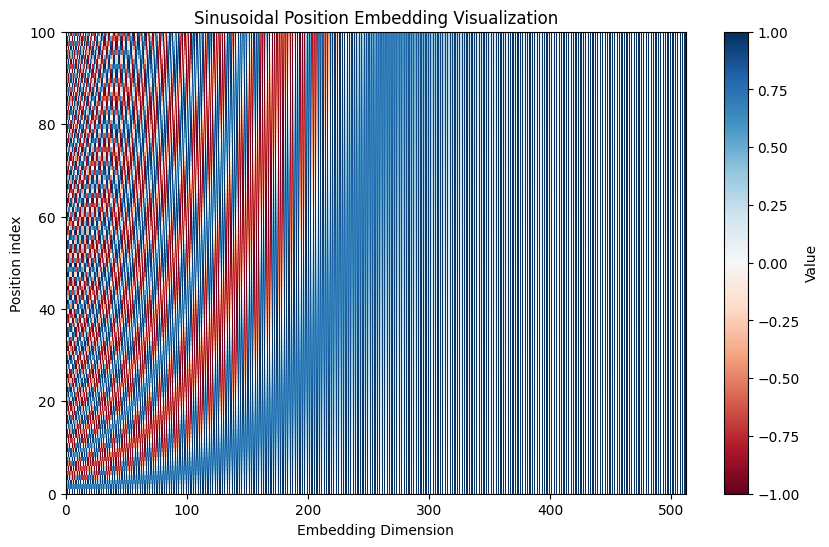

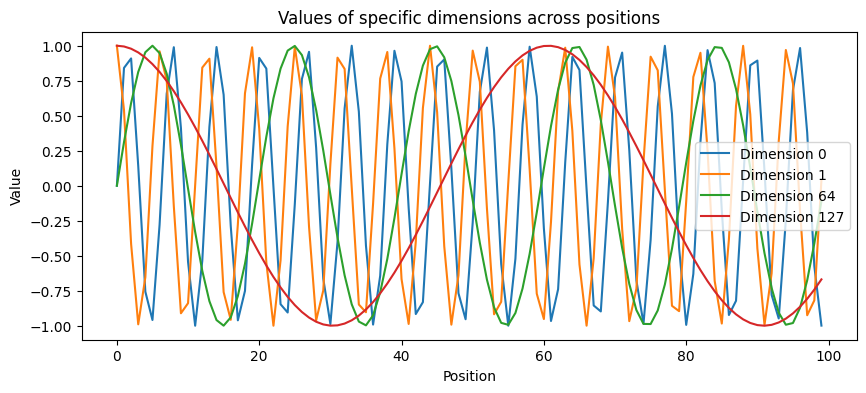

In [5]:
import matplotlib.pyplot as plt


def verify_position_embedding():
    # 1. 参数设置
    d_model = 512
    max_len = 100
    pos_emb_module = PositionEmbedding(d_model=d_model, max_len=max_len)

    # 2. 获取生成的编码矩阵 (shape: [max_len, d_model])
    # 注意：register_buffer 后的变量通过 self.pe 访问
    pe = pos_emb_module.pe

    # 3. 基础维度验证
    print(f"PE Matrix Shape: {pe.shape}")
    assert pe.shape == (max_len, d_model), "维度不匹配！"

    # 4. 可视化验证
    plt.figure(figsize=(10, 6))
    # 绘制热力图，观察不同维度的周期性变化
    plt.pcolormesh(pe.numpy(), cmap="RdBu")
    plt.xlabel("Embedding Dimension")
    plt.ylabel("Position index")
    plt.colorbar(label="Value")
    plt.title("Sinusoidal Position Embedding Visualization")
    plt.show()

    # 5. 周期性验证：绘制其中几个维度的曲线
    plt.figure(figsize=(10, 4))
    for i in [0, 1, 64, 127]:
        plt.plot(pe[:, i].numpy(), label=f"Dimension {i}")
    plt.legend()
    plt.title("Values of specific dimensions across positions")
    plt.xlabel("Position")
    plt.ylabel("Value")
    plt.show()


if __name__ == "__main__":
    verify_position_embedding()


In [ ]:
class MultiHeadAttention(nn.Module):
    def __init__(self, d_model, num_heads, dropout):
        super().__init__()
        assert d_model % num_heads == 0

        self.d_model = d_model
        self.num_heads = num_heads
        self.d_k = d_model // num_heads
        self.dropout = nn.Dropout(dropout)

        self.Wq = nn.Linear(d_model, d_model)
        self.Wk = nn.Linear(d_model, d_model)
        self.Wv = nn.Linear(d_model, d_model)
        self.Wo = nn.Linear(d_model, d_model)

    def forward(self, Q, K, V, mask=None):
        batch_size = Q.size(0)

        Q = self.Wq(Q).view(batch_size, -1, self.num_heads, self.d_k).transpose(1, 2)
        K = self.Wk(K).view(batch_size, -1, self.num_heads, self.d_k).transpose(1, 2)
        V = self.Wv(V).view(batch_size, -1, self.num_heads, self.d_k).transpose(1, 2)

        scores = torch.matmul(Q, K.transpose(-1, -2)) / math.sqrt(self.d_k)

        if mask is not None:
            scores = scores.masked_fill(mask == 0, float("-inf"))

        attn_weights = self.dropout(torch.softmax(scores, -1))

        output = (
            torch.matmul(attn_weights, V)
            .transpose(1, 2)
            .contiguous()
            .view(batch_size, -1, self.d_k * self.num_heads)
        )

        output = self.Wo(output)
        return output, attn_weights


In [ ]:
class FFN(nn.Module):
    def __init__(self, d_model, d_ff):
        super().__init__()
        self.linear1 = nn.Linear(d_model,d_ff)
        self.linear2 = nn.Linear(d_ff,d_model)
        self.activation = nn.ReLU()

    def forward(self,x):
        output = self.linear2(self.activation(self.linear1(x)))
        return output


In [ ]:
class EncodeLayer(nn.Module):
    def __init__(self,d_model, num_heads,d_ff,dropout =0.1):
        super().__init__()
        self.d_model = d_model
        self.MultiHeadAttention = MultiHeadAttention(d_model,num_heads)
        self.FFN = FFN(d_model,d_ff)
        self.norm1 = nn.LayerNorm(d_model)
        self.norm2 = nn.LayerNorm(d_model)
        self.dropout = nn.Dropout(dropout)

    def forward(self,x):
        attn_output,attn_weights = self.MultiHeadAttention(x,x,x)

        x = self.norm1(x + self.dropout(attn_output))
        x = self.norm2(x + self.dropout(self.FFN(x)))

        return x


